In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os, sys
import json
import torch
import pandas as pd
import numpy as np
SAVE_PATH = '/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/data'
REPO_ROOT = os.path.dirname(SAVE_PATH)
sys.path.append(REPO_ROOT)
OUTPUTS_PATH = REPO_ROOT + '/outputs/eval/'

In [28]:
print(OUTPUTS_PATH)

/content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/outputs/eval/


In [6]:
checkpoint = torch.load(REPO_ROOT + '/checkpoints/best_model_phase2.pt', map_location='cpu')
print(type(checkpoint))
print(len(checkpoint))

KeyboardInterrupt: 

In [6]:
log = pd.read_csv(REPO_ROOT + '/outputs/training_log_phase1.csv')
print(log)

   epoch  avg_train_loss  avg_val_loss  goal_relevance_rmse  \
0      1        0.019825      0.147372             0.355936   
1      2        0.018569      0.136912             0.343347   
2      3        0.018017      0.133792             0.339273   
3      4        0.017676      0.134939             0.335984   
4      5        0.017474      0.131758             0.333274   
5      6        0.017322      0.128838             0.335467   
6      7        0.017199      0.129279             0.330953   
7      8        0.017076      0.129533             0.329640   

   self_responsblt_rmse  other_responsblt_rmse  chance_responsblt_rmse  \
0              0.395218               0.402858                0.403222   
1              0.385797               0.393667                0.398074   
2              0.387316               0.390474                0.385899   
3              0.373772               0.389223                0.402578   
4              0.374959               0.390233                

In [9]:
# Table 8 from Troiano et al. (2023): RoBERTa-large T->A model RMSE (1-5 scale)
# Mapped to 15 target dimensions
paper_rmse = {
    'goal_relevance':    1.57,
    'self_responsblt':   1.40,
    'other_responsblt':  1.57,
    'chance_responsblt': 1.43,
    'goal_support':      1.33,
    'predict_conseq':    1.50,
    'urgency':           1.43,
    'self_control':      1.35,
    'other_control':     1.36,
    'chance_control':    1.35,
    'accept_conseq':     1.44,
    'social_norms':      1.34,
    'standards':         1.36,
    'attention':         1.27,
    'effort':            1.38,
}

In [13]:
import matplotlib.pyplot as plt

def analyze_training_log(phase_name):
    
    log = pd.read_csv(REPO_ROOT + f'/outputs/training_log_{phase_name}.csv')

    plt.figure(figsize=(10, 5))
    plt.plot(log['epoch'], log['avg_train_loss'], label='Train Loss')
    plt.plot(log['epoch'], log['avg_val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.show()
    print("Best epoch row:")
    best_epoch_row = log.loc[log['avg_val_loss'].idxmin()]
    print(best_epoch_row)
    print("Per-dimension RMSE table for best epoch:")
    rmse_columns = [col for col in log.columns if col.endswith('_rmse')]
    rmse_dict = {col.replace('_rmse', ''): best_epoch_row[col] for col in rmse_columns}
    rmse_df = pd.DataFrame(list(rmse_dict.items()), columns=['Dimension', 'RMSE'])
    return rmse_dict, rmse_df

def compare_to_paper(rmse_dict, paper_rmse_dict):
    dims = list(rmse_dict.keys())
    comparison_df = pd.DataFrame({
        'dimension': dims,
        'model_rmse_scaled': [rmse_dict[d] * 4 for d in dims],
        'paper_rmse': [paper_rmse_dict[d] for d in dims],
        'difference': [rmse_dict[d] * 4 - paper_rmse_dict[d] for d in dims],
        'better_than_paper': [rmse_dict[d] * 4 < paper_rmse_dict[d] for d in dims]
    })
    worse_than_paper_df = comparison_df.loc[
        comparison_df['better_than_paper'] == False, 
        ['dimension', 'difference']
    ].copy()
    worse_than_paper_df['difference'] = worse_than_paper_df['difference'].round(4)
    return worse_than_paper_df, comparison_df

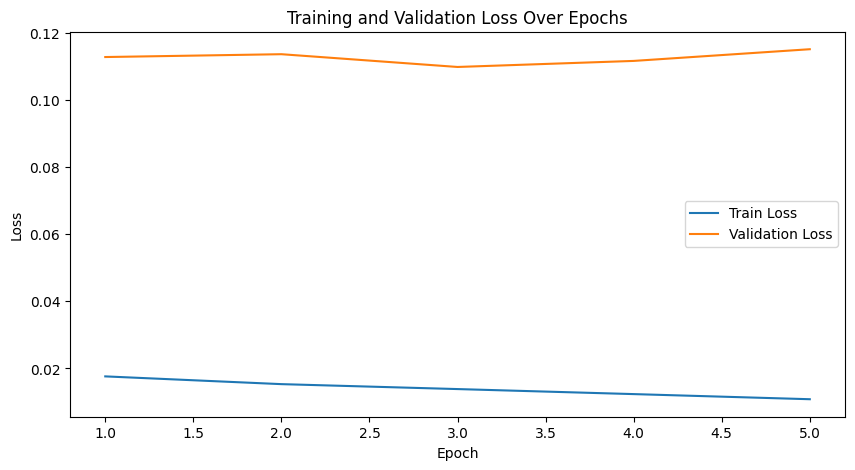

Best epoch row:
epoch                     3.000000
avg_train_loss            0.013860
avg_val_loss              0.109815
goal_relevance_rmse       0.317266
self_responsblt_rmse      0.325765
other_responsblt_rmse     0.330146
chance_responsblt_rmse    0.364745
goal_support_rmse         0.285044
predict_conseq_rmse       0.333440
urgency_rmse              0.337986
self_control_rmse         0.314882
other_control_rmse        0.321206
chance_control_rmse       0.360424
accept_conseq_rmse        0.359123
social_norms_rmse         0.326744
standards_rmse            0.333721
attention_rmse            0.337353
effort_rmse               0.313948
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.31726557), 'self_responsblt': np.float64(0.32576537), 'other_responsblt': np.float64(0.330146), 'chance_responsblt': np.float64(0.36474514), 'goal_support': np.float64(0.28504393), 'predict_conseq': np.float64(0.33343974), 'urgency': np.float64(0.33798596),

In [9]:
# Analyze the first training log
rmse_dict_p1unfrozen, rmse_df = analyze_training_log("phase1_unfrozen")
worse_than_paper_df_p1unfrozen,comparison_df = compare_to_paper(rmse_dict_p1unfrozen, paper_rmse)
print(rmse_dict_p1unfrozen)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p1unfrozen.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p1unfrozen)

# Run 2?

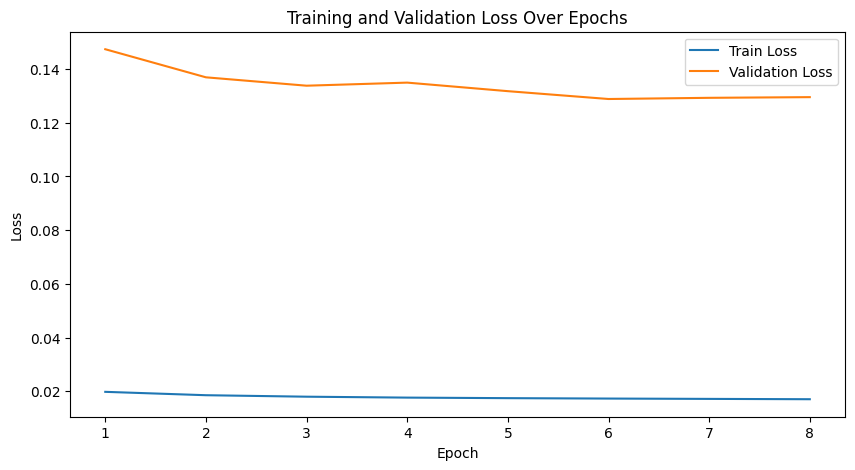

Best epoch row:
epoch                     6.000000
avg_train_loss            0.017322
avg_val_loss              0.128838
goal_relevance_rmse       0.335467
self_responsblt_rmse      0.369659
other_responsblt_rmse     0.384979
chance_responsblt_rmse    0.377819
goal_support_rmse         0.337560
predict_conseq_rmse       0.347813
urgency_rmse              0.353810
self_control_rmse         0.344180
other_control_rmse        0.374763
chance_control_rmse       0.371587
accept_conseq_rmse        0.356370
social_norms_rmse         0.366306
standards_rmse            0.360441
attention_rmse            0.358813
effort_rmse               0.339858
Name: 5, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.33546692), 'self_responsblt': np.float64(0.3696586), 'other_responsblt': np.float64(0.38497922), 'chance_responsblt': np.float64(0.377819), 'goal_support': np.float64(0.33755973), 'predict_conseq': np.float64(0.3478127), 'urgency': np.float64(0.35381013), '

In [10]:
# Analyze the first training log again to confirm results are consistent
rmse_dict_p1frozen, rmse_df = analyze_training_log("phase1")
worse_than_paper_df_p1frozen,comparison_df = compare_to_paper(rmse_dict_p1frozen, paper_rmse)
print(rmse_dict_p1frozen)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p1frozen.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p1frozen)

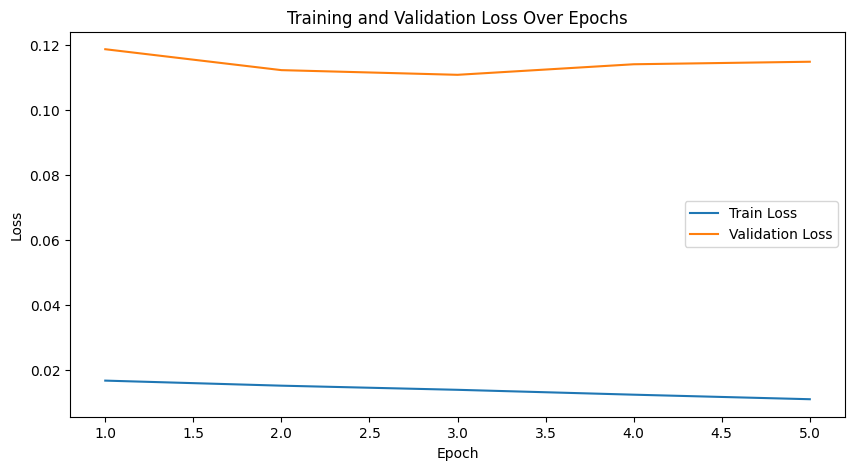

Best epoch row:
epoch                     3.000000
avg_train_loss            0.013899
avg_val_loss              0.110713
goal_relevance_rmse       0.325893
self_responsblt_rmse      0.328102
other_responsblt_rmse     0.332332
chance_responsblt_rmse    0.361626
goal_support_rmse         0.297691
predict_conseq_rmse       0.335345
urgency_rmse              0.332570
self_control_rmse         0.319457
other_control_rmse        0.322277
chance_control_rmse       0.370827
accept_conseq_rmse        0.370186
social_norms_rmse         0.317980
standards_rmse            0.331279
attention_rmse            0.314063
effort_rmse               0.322468
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.32589298), 'self_responsblt': np.float64(0.3281016), 'other_responsblt': np.float64(0.332332), 'chance_responsblt': np.float64(0.36162552), 'goal_support': np.float64(0.29769114), 'predict_conseq': np.float64(0.33534512), 'urgency': np.float64(0.3325699), '

In [11]:
# Analyze the second training log 
rmse_dict_p2, rmse_df = analyze_training_log("phase2")
worse_than_paper_df_p2,comparison_df = compare_to_paper(rmse_dict_p2, paper_rmse)
print(rmse_dict_p2)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p2   .values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p2)

In [12]:
target_dims = [
    'goal_relevance', 'self_responsblt', 'other_responsblt', 'chance_responsblt',
    'goal_support', 'predict_conseq', 'urgency', 'self_control', 'other_control',
    'chance_control', 'accept_conseq', 'social_norms', 'standards', 'attention', 'effort'
]

comparison_full = pd.DataFrame({
    'dimension': target_dims,
    'paper': [paper_rmse[d] for d in target_dims],
    'phase1_unfrozen': [rmse_dict_p1unfrozen[d] * 4 for d in target_dims],
    'phase1_frozen': [rmse_dict_p1frozen[d] * 4 for d in target_dims],
    'phase2': [rmse_dict_p2[d] * 4 for d in target_dims],
})

# Add improvement columns
comparison_full['p1u_vs_paper'] = comparison_full['phase1_unfrozen'] - comparison_full['paper']
comparison_full['p1f_vs_paper'] = comparison_full['phase1_frozen'] - comparison_full['paper']
comparison_full['p2_vs_paper'] = comparison_full['phase2'] - comparison_full['paper']
comparison_full['p2_vs_p1unfrozen'] = comparison_full['phase2'] - comparison_full['phase1_unfrozen']

# Sort by p2_vs_paper to see worst dimensions first
comparison_full = comparison_full.sort_values('p2_vs_p1unfrozen', ascending=False)
print(comparison_full.to_string())

            dimension  paper  phase1_unfrozen  phase1_frozen    phase2  p1u_vs_paper  p1f_vs_paper  p2_vs_paper  p2_vs_p1unfrozen
4        goal_support   1.33         1.140176       1.350239  1.190765     -0.189824      0.020239    -0.139235          0.050589
10      accept_conseq   1.44         1.436492       1.425478  1.480742     -0.003508     -0.014522     0.040742          0.044250
9      chance_control   1.35         1.441697       1.486349  1.483308      0.091697      0.136349     0.133308          0.041612
0      goal_relevance   1.57         1.269062       1.341868  1.303572     -0.300938     -0.228132    -0.266428          0.034510
14             effort   1.38         1.255790       1.359433  1.289873     -0.124210     -0.020567    -0.090127          0.034082
7        self_control   1.35         1.259529       1.376720  1.277826     -0.090471      0.026720    -0.072174          0.018297
1     self_responsblt   1.40         1.303061       1.478634  1.312406     -0.096939      

In [13]:
comparison_full_md = comparison_full.to_markdown()
print(comparison_full_md)

|    | dimension         |   paper |   phase1_unfrozen |   phase1_frozen |   phase2 |   p1u_vs_paper |   p1f_vs_paper |   p2_vs_paper |   p2_vs_p1unfrozen |
|---:|:------------------|--------:|------------------:|----------------:|---------:|---------------:|---------------:|--------------:|-------------------:|
|  4 | goal_support      |    1.33 |           1.14018 |         1.35024 |  1.19076 |     -0.189824  |      0.0202389 |    -0.139235  |         0.0505888  |
| 10 | accept_conseq     |    1.44 |           1.43649 |         1.42548 |  1.48074 |     -0.0035076 |     -0.0145219 |     0.0407422 |         0.0442498  |
|  9 | chance_control    |    1.35 |           1.4417  |         1.48635 |  1.48331 |      0.0916968 |      0.136349  |     0.133308  |         0.0416115  |
|  0 | goal_relevance    |    1.57 |           1.26906 |         1.34187 |  1.30357 |     -0.300938  |     -0.228132  |    -0.266428  |         0.0345096  |
| 14 | effort            |    1.38 |           1.25579 |  

In [14]:
# Average scaled RMSE for each phase
print("Average scaled RMSE for phase 1 unfrozen:", np.mean(list(rmse_dict_p1unfrozen.values())).round(4) * 4)
print("Average scaled RMSE for phase 1 frozen:", np.mean(list(rmse_dict_p1frozen.values())).round(4) * 4)
print("Average scaled RMSE for phase 2:", np.mean(list(rmse_dict_p2.values())).round(4) * 4)
print("Average scaled RMSE of the original paper:", np.mean(list(paper_rmse.values())).round(4))

Average scaled RMSE for phase 1 unfrozen: 1.3232
Average scaled RMSE for phase 1 frozen: 1.4344
Average scaled RMSE for phase 2: 1.3284
Average scaled RMSE of the original paper: 1.4053


In [15]:
import matplotlib.pyplot as plt

def plot_loss_record(phase_name): 
    loss_record = pd.read_csv(os.path.join(REPO_ROOT, f'outputs/batch_losses_{phase_name}.csv'))['batch_loss'].values

    plt.plot(loss_record, alpha=0.3, label='Batch loss')

    smoothed = pd.Series(loss_record).rolling(window=50).mean()
    plt.plot(smoothed, label='Smoothed (window=50)')

    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.show()

# 2nd Run of Both Phases

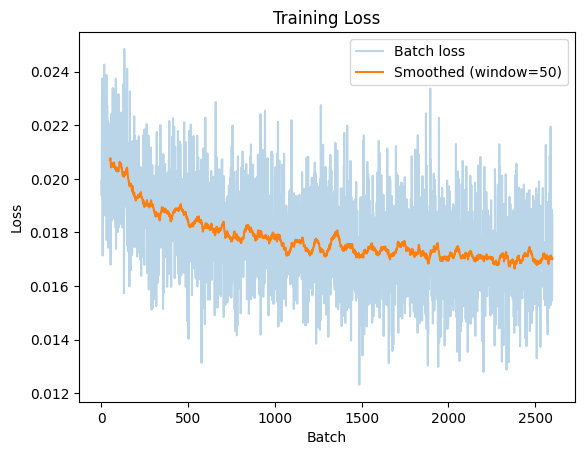

In [16]:
plot_loss_record('phase1')

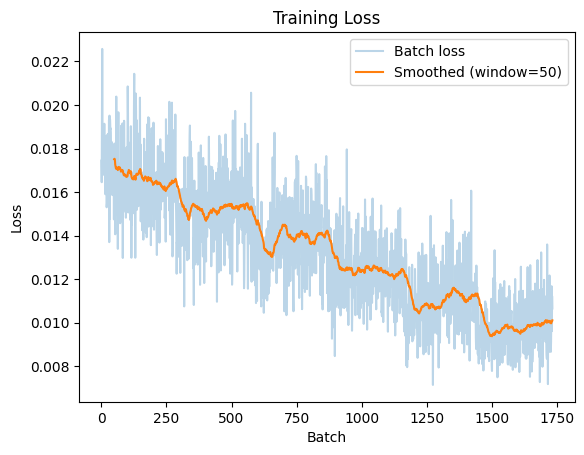

In [17]:
plot_loss_record('phase2')

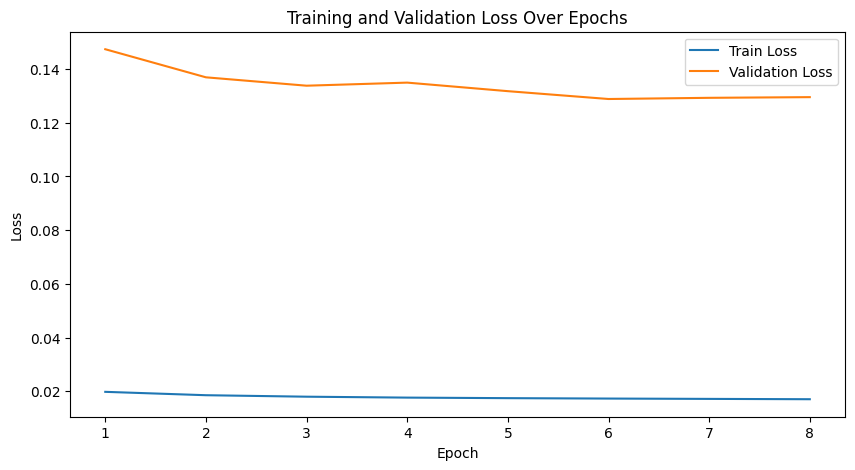

Best epoch row:
epoch                     6.000000
avg_train_loss            0.017322
avg_val_loss              0.128838
goal_relevance_rmse       0.335467
self_responsblt_rmse      0.369659
other_responsblt_rmse     0.384979
chance_responsblt_rmse    0.377819
goal_support_rmse         0.337560
predict_conseq_rmse       0.347813
urgency_rmse              0.353810
self_control_rmse         0.344180
other_control_rmse        0.374763
chance_control_rmse       0.371587
accept_conseq_rmse        0.356370
social_norms_rmse         0.366306
standards_rmse            0.360441
attention_rmse            0.358813
effort_rmse               0.339858
Name: 5, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.33546692), 'self_responsblt': np.float64(0.3696586), 'other_responsblt': np.float64(0.38497922), 'chance_responsblt': np.float64(0.377819), 'goal_support': np.float64(0.33755973), 'predict_conseq': np.float64(0.3478127), 'urgency': np.float64(0.35381013), '

In [18]:
rmse_dict_p1unfrozen, rmse_df = analyze_training_log("phase1")
worse_than_paper_df_p1unfrozen,comparison_df = compare_to_paper(rmse_dict_p1unfrozen, paper_rmse)
print(rmse_dict_p1unfrozen)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p1unfrozen.values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p1unfrozen)

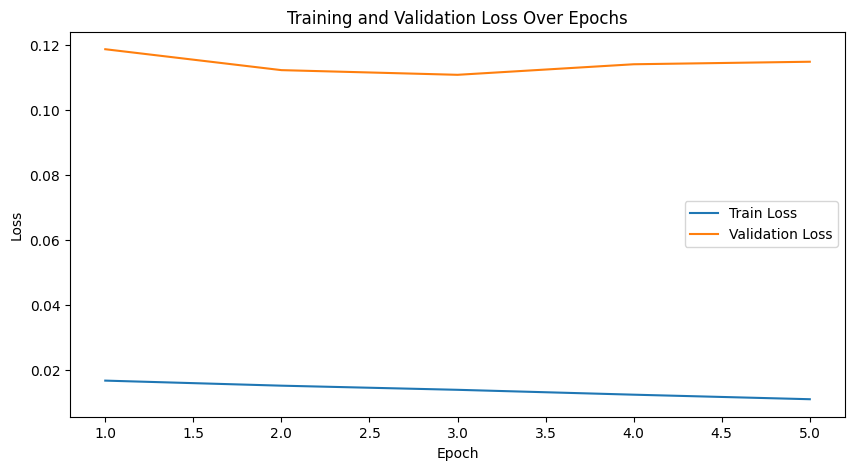

Best epoch row:
epoch                     3.000000
avg_train_loss            0.013899
avg_val_loss              0.110713
goal_relevance_rmse       0.325893
self_responsblt_rmse      0.328102
other_responsblt_rmse     0.332332
chance_responsblt_rmse    0.361626
goal_support_rmse         0.297691
predict_conseq_rmse       0.335345
urgency_rmse              0.332570
self_control_rmse         0.319457
other_control_rmse        0.322277
chance_control_rmse       0.370827
accept_conseq_rmse        0.370186
social_norms_rmse         0.317980
standards_rmse            0.331279
attention_rmse            0.314063
effort_rmse               0.322468
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.32589298), 'self_responsblt': np.float64(0.3281016), 'other_responsblt': np.float64(0.332332), 'chance_responsblt': np.float64(0.36162552), 'goal_support': np.float64(0.29769114), 'predict_conseq': np.float64(0.33534512), 'urgency': np.float64(0.3325699), '

In [19]:
# Analyze the second training log 
rmse_dict_p2, rmse_df = analyze_training_log("phase2")
worse_than_paper_df_p2,comparison_df = compare_to_paper(rmse_dict_p2, paper_rmse)
print(rmse_dict_p2)
print(rmse_df)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_p2   .values())).round(4) * 4)
print(comparison_df)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_p2)

In [20]:
comparison_full_r2 = pd.DataFrame({
    'dimension': target_dims,
    'paper': [paper_rmse[d] for d in target_dims],
    'phase1_unfrozen': [rmse_dict_p1unfrozen[d] * 4 for d in target_dims],
    'phase1_frozen': [rmse_dict_p1frozen[d] * 4 for d in target_dims],
    'phase2': [rmse_dict_p2[d] * 4 for d in target_dims],
})

# Add improvement columns
comparison_full_r2['p1u_vs_paper'] = comparison_full_r2['phase1_unfrozen'] - comparison_full_r2['paper']
comparison_full_r2['p1f_vs_paper'] = comparison_full_r2['phase1_frozen'] - comparison_full_r2['paper']
comparison_full_r2['p2_vs_paper'] = comparison_full_r2['phase2'] - comparison_full_r2['paper']
comparison_full_r2['p2_vs_p1unfrozen'] = comparison_full_r2['phase2'] - comparison_full_r2['phase1_unfrozen']
comparison_full_r2['p2_vs_p1f'] = comparison_full_r2['phase2'] - comparison_full_r2['phase1_frozen']

# Sort by p2_vs_paper to see worst dimensions first
comparison_full_r2 = comparison_full_r2.set_index('dimension')
comparison_full_r2 = comparison_full_r2.sort_index()
print(comparison_full_r2.to_markdown())

| dimension         |   paper |   phase1_unfrozen |   phase1_frozen |   phase2 |   p1u_vs_paper |   p1f_vs_paper |   p2_vs_paper |   p2_vs_p1unfrozen |   p2_vs_p1f |
|:------------------|--------:|------------------:|----------------:|---------:|---------------:|---------------:|--------------:|-------------------:|------------:|
| accept_conseq     |    1.44 |           1.42548 |         1.42548 |  1.48074 |     -0.0145219 |     -0.0145219 |     0.0407422 |          0.0552641 |   0.0552641 |
| attention         |    1.27 |           1.43525 |         1.43525 |  1.25625 |      0.165252  |      0.165252  |    -0.0137489 |         -0.179001  |  -0.179001  |
| chance_control    |    1.35 |           1.48635 |         1.48635 |  1.48331 |      0.136349  |      0.136349  |     0.133308  |         -0.0030408 |  -0.0030408 |
| chance_responsblt |    1.43 |           1.51128 |         1.51128 |  1.4465  |      0.081276  |      0.081276  |     0.0165021 |         -0.0647739 |  -0.0647739 |
| ef

# 3rd Run of Both Phases

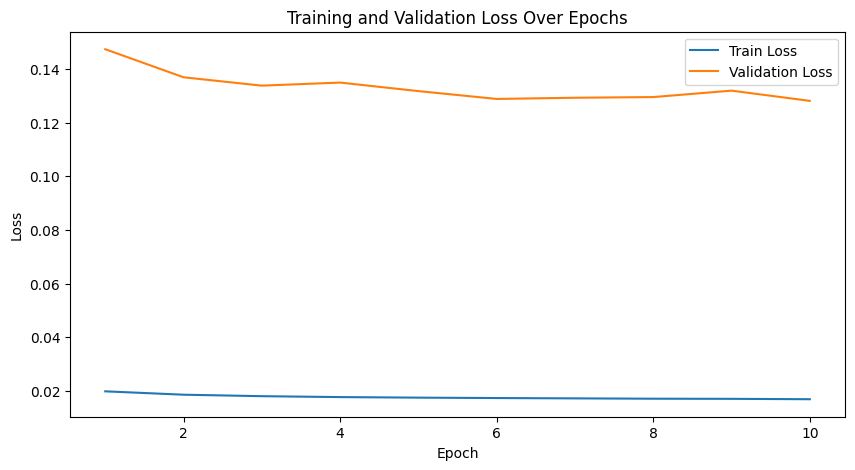

Best epoch row:
epoch                     10.000000
avg_train_loss             0.016883
avg_val_loss               0.128121
goal_relevance_rmse        0.328792
self_responsblt_rmse       0.367323
other_responsblt_rmse      0.381470
chance_responsblt_rmse     0.394927
goal_support_rmse          0.333900
predict_conseq_rmse        0.344376
urgency_rmse               0.347182
self_control_rmse          0.336322
other_control_rmse         0.367817
chance_control_rmse        0.380839
accept_conseq_rmse         0.354520
social_norms_rmse          0.376314
standards_rmse             0.366358
attention_rmse             0.342580
effort_rmse                0.338167
Name: 9, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.32879233), 'self_responsblt': np.float64(0.36732298), 'other_responsblt': np.float64(0.38146982), 'chance_responsblt': np.float64(0.39492738), 'goal_support': np.float64(0.33389974), 'predict_conseq': np.float64(0.34437576), 'urgency': np.

In [21]:
# Analyze the first training log again to confirm results are consistent
# Running on wd01_do02_p5_frozen

phase_name = 'wd01_do02_p5_frozen'

rmse_dict_wd01_do02_p5_frozen, rmse_df_wd01_do02_p5_frozen = analyze_training_log(phase_name)
worse_than_paper_df_wd01_do02_p5_frozen,comparison_df_wd01_do02_p5_frozen = compare_to_paper(rmse_dict_wd01_do02_p5_frozen, paper_rmse)
print(rmse_dict_wd01_do02_p5_frozen)
print(rmse_df_wd01_do02_p5_frozen)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_wd01_do02_p5_frozen.values())).round(4) * 4)
print(comparison_df_wd01_do02_p5_frozen)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_wd01_do02_p5_frozen)

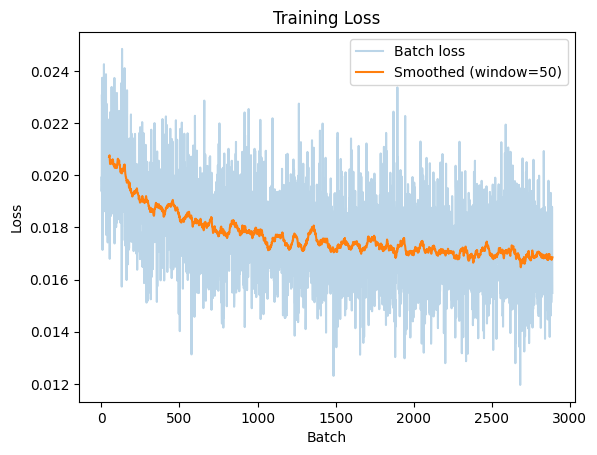

In [22]:
plot_loss_record(phase_name)

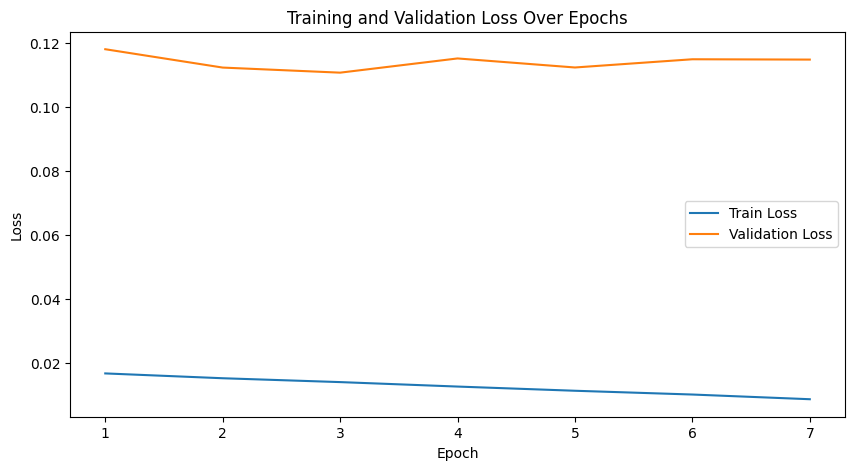

Best epoch row:
epoch                     3.000000
avg_train_loss            0.014059
avg_val_loss              0.110788
goal_relevance_rmse       0.325815
self_responsblt_rmse      0.334157
other_responsblt_rmse     0.330250
chance_responsblt_rmse    0.355217
goal_support_rmse         0.303232
predict_conseq_rmse       0.335351
urgency_rmse              0.332292
self_control_rmse         0.321061
other_control_rmse        0.323365
chance_control_rmse       0.361781
accept_conseq_rmse        0.368885
social_norms_rmse         0.318053
standards_rmse            0.331903
attention_rmse            0.315397
effort_rmse               0.329443
Name: 2, dtype: float64
Per-dimension RMSE table for best epoch:
{'goal_relevance': np.float64(0.32581517), 'self_responsblt': np.float64(0.33415666), 'other_responsblt': np.float64(0.3302496), 'chance_responsblt': np.float64(0.35521716), 'goal_support': np.float64(0.3032324), 'predict_conseq': np.float64(0.33535072), 'urgency': np.float64(0.3322917), 

In [14]:
# Analyze the first training log again to confirm results are consistent
# Running on wd01_do02_p5_ft
phase_name = 'wd01_do02_p5_ft'

rmse_dict_wd01_do02_p5_ft, rmse_df_wd01_do02_p5_ft = analyze_training_log(phase_name)
worse_than_paper_df_wd01_do02_p5_ft,comparison_df_wd01_do02_p5_ft = compare_to_paper(rmse_dict_wd01_do02_p5_ft, paper_rmse)
print(rmse_dict_wd01_do02_p5_ft)
print(rmse_df_wd01_do02_p5_ft)
print("Average scaled RMSE across dimensions:", np.mean(list(rmse_dict_wd01_do02_p5_ft.values())).round(4) * 4)
print(comparison_df_wd01_do02_p5_ft)
print("Dimensions where model performs worse than paper:")
print(worse_than_paper_df_wd01_do02_p5_ft)

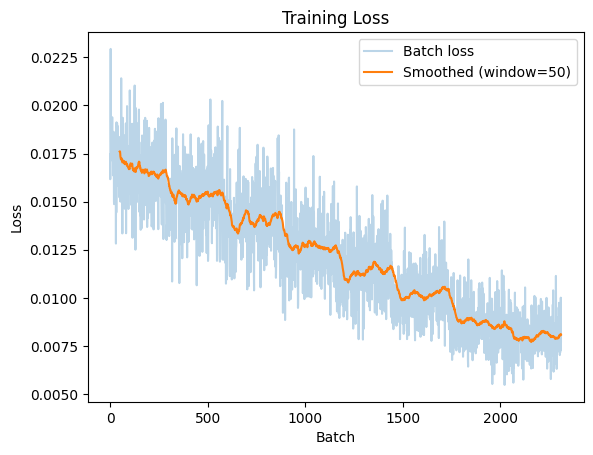

In [24]:
plot_loss_record(phase_name)

In [25]:
comparison_full_r3 = pd.DataFrame({
    'dimension': target_dims,
    'paper': [paper_rmse[d] for d in target_dims],
    'P1': [rmse_dict_wd01_do02_p5_frozen[d] * 4 for d in target_dims],
    'P2': [rmse_dict_wd01_do02_p5_ft[d] * 4 for d in target_dims],
})

# Add improvement columns
comparison_full_r3['P1-Paper'] = comparison_full_r3['P1'] - comparison_full_r3['paper']
comparison_full_r3['P2-Paper'] = comparison_full_r3['P2'] - comparison_full_r3['paper']
comparison_full_r3['P2-P1'] = comparison_full_r3['P2'] - comparison_full_r3['P1']

# Sort by p2_vs_paper to see worst dimensions first
comparison_full_r3 = comparison_full_r3.set_index('dimension')
comparison_full_r3 = comparison_full_r3.sort_index()
print(comparison_full_r3.to_markdown())

| dimension         |   paper |      P1 |      P2 |    P1-Paper |    P2-Paper |      P2-P1 |
|:------------------|--------:|--------:|--------:|------------:|------------:|-----------:|
| accept_conseq     |    1.44 | 1.41808 | 1.47554 | -0.0219209  |  0.0355397  |  0.0574606 |
| attention         |    1.27 | 1.37032 | 1.26159 |  0.100321   | -0.008412   | -0.108733  |
| chance_control    |    1.35 | 1.52336 | 1.44713 |  0.173355   |  0.0971251  | -0.07623   |
| chance_responsblt |    1.43 | 1.57971 | 1.42087 |  0.14971    | -0.00913136 | -0.158841  |
| effort            |    1.38 | 1.35267 | 1.31777 | -0.0273318  | -0.0622298  | -0.0348979 |
| goal_relevance    |    1.57 | 1.31517 | 1.30326 | -0.254831   | -0.266739   | -0.0119086 |
| goal_support      |    1.33 | 1.3356  | 1.21293 |  0.00559896 | -0.11707    | -0.122669  |
| other_control     |    1.36 | 1.47127 | 1.29346 |  0.111267   | -0.0665388  | -0.177806  |
| other_responsblt  |    1.57 | 1.52588 | 1.321   | -0.0441207  | -0.2

In [26]:
print(comparison_full_r2.to_markdown())
print()
print(comparison_full_r3.to_markdown())

| dimension         |   paper |   phase1_unfrozen |   phase1_frozen |   phase2 |   p1u_vs_paper |   p1f_vs_paper |   p2_vs_paper |   p2_vs_p1unfrozen |   p2_vs_p1f |
|:------------------|--------:|------------------:|----------------:|---------:|---------------:|---------------:|--------------:|-------------------:|------------:|
| accept_conseq     |    1.44 |           1.42548 |         1.42548 |  1.48074 |     -0.0145219 |     -0.0145219 |     0.0407422 |          0.0552641 |   0.0552641 |
| attention         |    1.27 |           1.43525 |         1.43525 |  1.25625 |      0.165252  |      0.165252  |    -0.0137489 |         -0.179001  |  -0.179001  |
| chance_control    |    1.35 |           1.48635 |         1.48635 |  1.48331 |      0.136349  |      0.136349  |     0.133308  |         -0.0030408 |  -0.0030408 |
| chance_responsblt |    1.43 |           1.51128 |         1.51128 |  1.4465  |      0.081276  |      0.081276  |     0.0165021 |         -0.0647739 |  -0.0647739 |
| ef

In [ ]:
master = pd.DataFrame({
    'paper': paper_rmse,
    'r2_p2': {d: rmse_dict_p2[d] * 4 for d in target_dims},
    'r3_p2': {d: rmse_dict_wd01_do02_p5_ft[d] * 4 for d in target_dims},
})

# This - paper 
master['r2_vs_paper'] = master['r2_p2'] - master['paper']
master['r3_vs_paper'] = master['r3_p2'] - master['paper']

# (n+1)th run - (n)th run
master['r3_vs_r2'] = master['r3_p2'] - master['r2_p2']

# See worse r3-paper values first
master = master.sort_values('r3_vs_paper', ascending=False)
print(master.round(4).to_markdown())

|                   |   paper |   r2_p2 |   r3_p2 |   r2_vs_paper |   r3_vs_paper |   r3_vs_r2 |
|:------------------|--------:|--------:|--------:|--------------:|--------------:|-----------:|
| chance_control    |    1.35 |  1.4833 |  1.4471 |        0.1333 |        0.0971 |    -0.0362 |
| accept_conseq     |    1.44 |  1.4807 |  1.4755 |        0.0407 |        0.0355 |    -0.0052 |
| attention         |    1.27 |  1.2563 |  1.2616 |       -0.0137 |       -0.0084 |     0.0053 |
| chance_responsblt |    1.43 |  1.4465 |  1.4209 |        0.0165 |       -0.0091 |    -0.0256 |
| standards         |    1.36 |  1.3251 |  1.3276 |       -0.0349 |       -0.0324 |     0.0025 |
| effort            |    1.38 |  1.2899 |  1.3178 |       -0.0901 |       -0.0622 |     0.0279 |
| self_responsblt   |    1.4  |  1.3124 |  1.3366 |       -0.0876 |       -0.0634 |     0.0242 |
| self_control      |    1.35 |  1.2778 |  1.2842 |       -0.0722 |       -0.0658 |     0.0064 |
| other_control     |    1.36 

In [28]:
log_r2 = pd.read_csv(REPO_ROOT + '/outputs/training_log_phase2.csv')
log_r3 = pd.read_csv(REPO_ROOT + '/outputs/training_log_wd01_do02_p5_ft.csv')

# Get best epoch rows
best_r2 = log_r2.loc[log_r2['avg_val_loss'].idxmin()]
best_r3 = log_r3.loc[log_r3['avg_val_loss'].idxmin()]

# Extract RMSE columns
rmse_cols = [col for col in log_r2.columns if col.endswith('_rmse')]
dims = [col.replace('_rmse', '') for col in rmse_cols]

master = pd.DataFrame({
    'dimension': dims,
    'paper': [paper_rmse[d] for d in dims],
    'r2_p2': [best_r2[col] * 4 for col in rmse_cols],
    'r3_p2': [best_r3[col] * 4 for col in rmse_cols],
}).set_index('dimension')

master['r2_vs_paper'] = master['r2_p2'] - master['paper']
master['r3_vs_paper'] = master['r3_p2'] - master['paper']
master['r3_vs_r2'] = master['r3_p2'] - master['r2_p2']

print(master.sort_values('r3_vs_paper', ascending=False).round(4).to_markdown())

| dimension         |   paper |   r2_p2 |   r3_p2 |   r2_vs_paper |   r3_vs_paper |   r3_vs_r2 |
|:------------------|--------:|--------:|--------:|--------------:|--------------:|-----------:|
| chance_control    |    1.35 |  1.4833 |  1.4471 |        0.1333 |        0.0971 |    -0.0362 |
| accept_conseq     |    1.44 |  1.4807 |  1.4755 |        0.0407 |        0.0355 |    -0.0052 |
| attention         |    1.27 |  1.2563 |  1.2616 |       -0.0137 |       -0.0084 |     0.0053 |
| chance_responsblt |    1.43 |  1.4465 |  1.4209 |        0.0165 |       -0.0091 |    -0.0256 |
| standards         |    1.36 |  1.3251 |  1.3276 |       -0.0349 |       -0.0324 |     0.0025 |
| effort            |    1.38 |  1.2899 |  1.3178 |       -0.0901 |       -0.0622 |     0.0279 |
| self_responsblt   |    1.4  |  1.3124 |  1.3366 |       -0.0876 |       -0.0634 |     0.0242 |
| self_control      |    1.35 |  1.2778 |  1.2842 |       -0.0722 |       -0.0658 |     0.0064 |
| other_control     |    1.36 

# Evaluating the Model

In [7]:
from transformers import AutoModel
from src.model import AppraisalModel
from src.eval import evaluate_model
from src.dataset import AppraisalDataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from datetime import datetime

timestamp = int(datetime.now().timestamp())
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

TARGET_DIMS = [
    'goal_relevance', 'self_responsblt', 'other_responsblt', 'chance_responsblt',
    'goal_support', 'predict_conseq', 'urgency', 'self_control', 'other_control',
    'chance_control', 'accept_conseq', 'social_norms', 'standards', 'attention', 'effort'
]
checkpoint_path = REPO_ROOT + '/checkpoints/best_model_wd01_do02_p5_ft.pt'
test_path = REPO_ROOT + '/data/test.csv'



device = 'cuda' if torch.cuda.is_available() else 'cpu'
roberta = AutoModel.from_pretrained('roberta-base')
model = AppraisalModel(base_model=roberta, num_labels=len(TARGET_DIMS), dropout_p=None)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

test_dataset = AppraisalDataset(csv_path=test_path, tokenizer=tokenizer, weights=None, target_dims=TARGET_DIMS)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

results = evaluate_model(model, test_loader, TARGET_DIMS, device)

metrics_df = pd.DataFrame({
    'dimension': TARGET_DIMS, 
    'rmse': [results['per_dim_rmse'][d] for d in TARGET_DIMS],
    'mae': [results['per_dim_mae'][d] for d in TARGET_DIMS]
})
metrics_df.to_csv(os.path.join(OUTPUTS_PATH, f'out_sample_test_metrics-{timestamp}.csv'), index=False)

samples_df = pd.DataFrame(results['all_preds'], columns=[f'pred_{d}' for d in TARGET_DIMS])
samples_df[[f'true_{d}' for d in TARGET_DIMS]] = results['all_labels']
samples_df['sample_loss'] = results['per_sample_loss']
samples_df.to_csv(os.path.join(OUTPUTS_PATH, f'test_predictions-{timestamp}.csv'), index=False)

print(f"Test metrics saved to {OUTPUTS_PATH} at timestamp {timestamp}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/990 [00:00<?, ? examples/s]

Test metrics saved to /content/drive/MyDrive/2026-1/NLP/appraisal/nlp-appraisal/outputs/eval at timestamp 1781330953



Avg paper RMSE:    1.4053
Avg val RMSE:      1.3297
Avg test RMSE:     1.3277
Avg test MAE:      1.1128
Beats paper:       13/15
Beats val:       7/15

| dimension         |   paper |   val_rmse |   test_rmse |   test_mae |   diff_vs_paper | beats_paper   |   test_vs_val | beats_val   |
|:------------------|--------:|-----------:|------------:|-----------:|----------------:|:--------------|--------------:|:------------|
| goal_support      |    1.33 |     1.2129 |      1.2077 |     0.9891 |         -0.1223 | True          |       -0.0052 | True        |
| attention         |    1.27 |     1.2616 |      1.2422 |     1.0293 |         -0.0278 | True          |       -0.0194 | True        |
| self_responsblt   |    1.4  |     1.3366 |      1.2576 |     1.0333 |         -0.1424 | True          |       -0.079  | True        |
| other_responsblt  |    1.57 |     1.321  |      1.286  |     1.0704 |         -0.284  | True          |       -0.035  | True        |
| social_norms      |    1.34 |

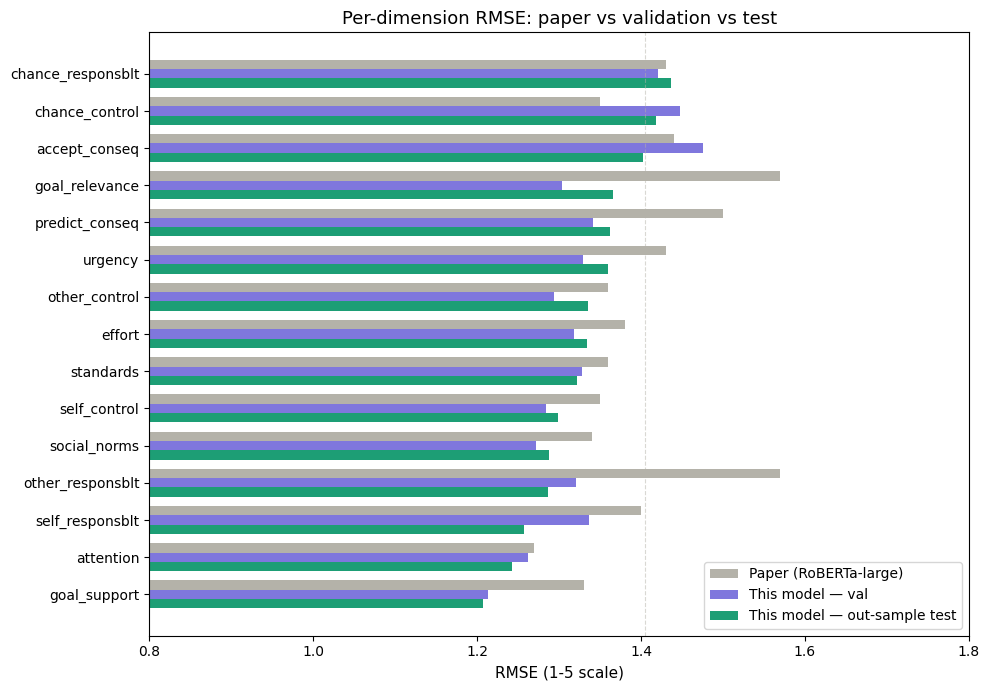

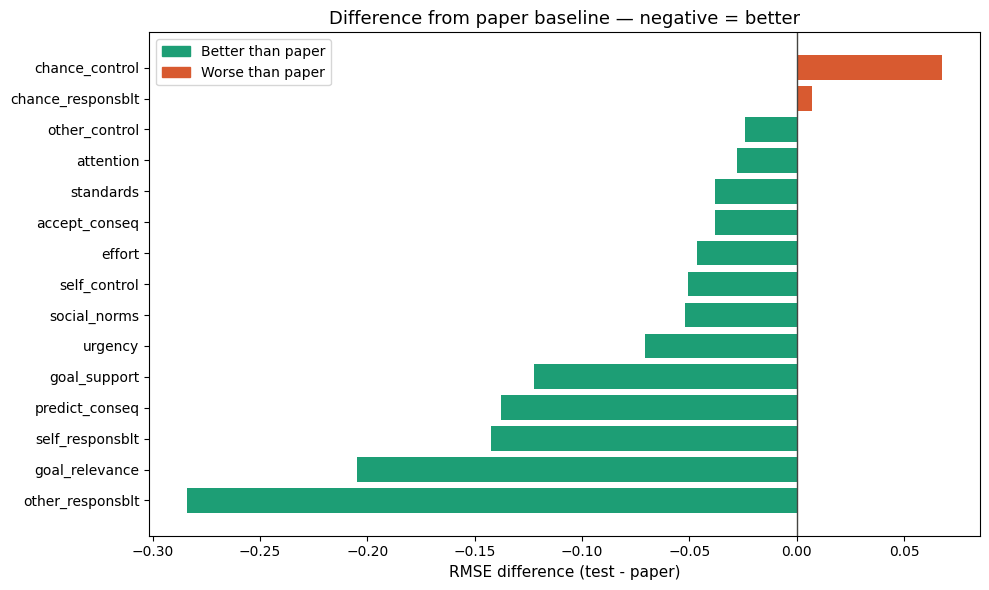

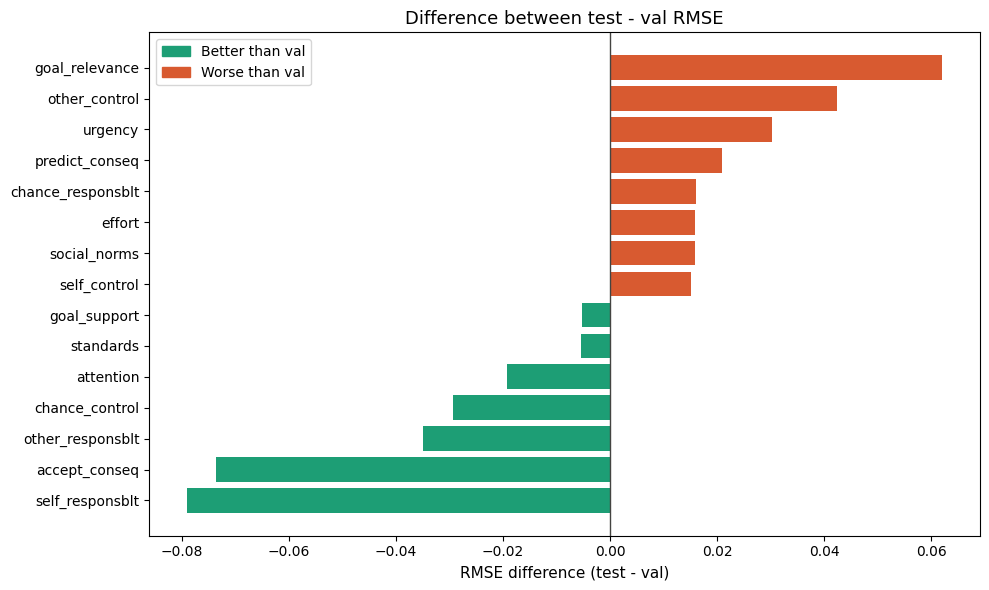

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

metrics = pd.read_csv(OUTPUTS_PATH + '/out_sample_test_metrics-1781330953.csv')
metrics['test_rmse_scaled'] = metrics['rmse'] * 4
metrics['test_mae_scaled'] = metrics['mae'] * 4
metrics['paper_rmse'] = [paper_rmse[d] for d in metrics['dimension']]
metrics['val_rmse_scaled'] = [rmse_dict_wd01_do02_p5_ft[d] * 4 for d in metrics['dimension']]
metrics['diff_vs_paper'] = metrics['test_rmse_scaled'] - metrics['paper_rmse']
metrics['beats_paper'] = metrics['diff_vs_paper'] < 0
metrics['test_vs_val'] = metrics['test_rmse_scaled'] - metrics['val_rmse_scaled']
metrics['beats_val'] = metrics['test_vs_val'] < 0
metrics = metrics.sort_values('test_rmse_scaled', ascending=True)

table_df = metrics[['dimension', 'paper_rmse', 'val_rmse_scaled', 'test_rmse_scaled', 'test_mae_scaled', 'diff_vs_paper', 'beats_paper', 'test_vs_val', 'beats_val']].copy()
table_df.columns = ['dimension', 'paper', 'val_rmse', 'test_rmse', 'test_mae', 'diff_vs_paper', 'beats_paper', 'test_vs_val', 'beats_val']
table_df = table_df.round(4)
print(f"\nAvg paper RMSE:    {table_df['paper'].mean():.4f}")
print(f"Avg val RMSE:      {table_df['val_rmse'].mean():.4f}")
print(f"Avg test RMSE:     {table_df['test_rmse'].mean():.4f}")
print(f"Avg test MAE:      {table_df['test_mae'].mean():.4f}")
print(f"Beats paper:       {table_df['beats_paper'].sum()}/15")
print(f"Beats val:       {table_df['beats_val'].sum()}/15")
print()
print(table_df.to_markdown(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(metrics))
h = 0.25

ax.barh(y + h, metrics['paper_rmse'],      height=h, color='#B4B2A9', label='Paper (RoBERTa-large)')  # gray
ax.barh(y,     metrics['val_rmse_scaled'],  height=h, color='#7F77DD', label='This model — val')        # purple
ax.barh(y - h, metrics['test_rmse_scaled'], height=h, color='#1D9E75', label='This model — out-sample test')       # teal

ax.set_yticks(y)
ax.set_yticklabels(metrics['dimension'], fontsize=10)
ax.set_xlabel('RMSE (1-5 scale)', fontsize=11)
ax.set_title('Per-dimension RMSE: paper vs validation vs test', fontsize=13, fontweight='500')
ax.legend(fontsize=10, loc='lower right')
ax.axvline(x=1.405, color='#B4B2A9', linestyle='--', linewidth=0.8, alpha=0.5, label='_nolegend_')
ax.set_xlim(0.8, 1.8)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + '/rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Diff from paper diverging bar 
metrics_div = metrics.sort_values('diff_vs_paper', ascending=True)
colors = ['#1D9E75' if v < 0 else '#D85A30' for v in metrics_div['diff_vs_paper']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(metrics_div)), metrics_div['diff_vs_paper'], color=colors)
ax.axvline(x=0, color='#444441', linewidth=1)
ax.set_yticks(range(len(metrics_div)))
ax.set_yticklabels(metrics_div['dimension'], fontsize=10)
ax.set_xlabel('RMSE difference (test - paper)', fontsize=11)
ax.set_title('Difference from paper baseline — negative = better', fontsize=13, fontweight='500')

better = mpatches.Patch(color='#1D9E75', label='Better than paper')
worse  = mpatches.Patch(color='#D85A30', label='Worse than paper')
ax.legend(handles=[better, worse], fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + '/diff_from_paper.png', dpi=150, bbox_inches='tight')
plt.show()


# Diff from paper diverging bar 
metrics_div_2 = metrics.sort_values('test_vs_val', ascending=True)
colors = ['#1D9E75' if v < 0 else '#D85A30' for v in metrics_div_2['test_vs_val']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(metrics_div_2)), metrics_div_2['test_vs_val'], color=colors)
ax.axvline(x=0, color='#444441', linewidth=1)
ax.set_yticks(range(len(metrics_div_2)))
ax.set_yticklabels(metrics_div_2['dimension'], fontsize=10)
ax.set_xlabel('RMSE difference (test - val)', fontsize=11)
ax.set_title('Difference between test - val RMSE', fontsize=13, fontweight='500')

better = mpatches.Patch(color='#1D9E75', label='Better than val')
worse  = mpatches.Patch(color='#D85A30', label='Worse than val')
ax.legend(handles=[better, worse], fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + '/test_vs_val.png', dpi=150, bbox_inches='tight')
plt.show()

# Saliency Analysis

`compute_saliency()` computes gradient saliency for one dimension across a batch and returns one score per token per sample. 

`run_full_saliency()` runs saliency across all dimensions and test batches. 

`aggregate_saliency_stats()` computes the mean gradient magnitude across all non-padding tokens and all samples for each dimension as well as the variance of per-sample mean gradient magnitudes (again, for each dimension). 

In [16]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm

def compute_saliency(model, batch, dim_idx, device):
    
    model.eval()
    input_ids     = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels        = batch['labels'].to(device)

    with torch.enable_grad():
        # Get word + position + token_type (full embedding)
        embeddings = model.base_model.embeddings(input_ids)
        embeddings.retain_grad()

        # Use embeddings directly to forward pass 
        outputs = model.base_model(inputs_embeds=embeddings, attention_mask=attention_mask)
        pooled  = outputs.last_hidden_state.mean(dim=1)
        pooled  = model.dropout(pooled)
        logits  = torch.sigmoid(model.linear(pooled))

        # Loss for this dimension
        loss = ((logits[:, dim_idx] - labels[:, dim_idx]) ** 2).mean()
        loss.backward()

    # Mean absolute gradient across hidden dim
    saliency = embeddings.grad.abs().mean(dim=-1) # (batch, seq_len)
    return saliency.detach().cpu().numpy()


def run_full_saliency(model, test_loader, target_dims, device):
    all_saliency = {dim: [] for dim in target_dims}

    for batch in tqdm(test_loader, desc='Computing saliency'):
        for dim_idx, dim in enumerate(target_dims):
            sal = compute_saliency(model, batch, dim_idx, device)
            all_saliency[dim].append(sal)

    return {dim: np.concatenate(all_saliency[dim], axis=0) for dim in target_dims}


def aggregate_saliency_stats(all_saliency, attention_mask_array):
    stats = {}
    for dim, sal in all_saliency.items():
        masked = sal * attention_mask_array 
        token_counts = attention_mask_array.sum(axis=1, keepdims=True)
        per_sample_mean = masked.sum(axis=1) / token_counts.squeeze() # (n_samples,)
        stats[dim] = {
            'mean': per_sample_mean.mean(),
            'variance': per_sample_mean.var(),
            'per_sample': per_sample_mean,
        }
    return stats

In [30]:
def plot_saliency_scatter(stats, target_dims, save_path=None):
    means = [stats[d]['mean'] for d in target_dims]
    variances = [stats[d]['variance'] for d in target_dims]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(means, variances, s=80, color='#378ADD', zorder=3)

    for dim, x, y in zip(target_dims, means, variances):
        ax.annotate(dim, (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=8.5,
                    color='#444441')

    ax.set_xlabel('Mean gradient magnitude (signal strength)', fontsize=11)
    ax.set_ylabel('Variance across samples (signal consistency)', fontsize=11)
    ax.set_title('Gradient saliency per dimension',
                 fontsize=12, fontweight='500')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# This shows a gradient saliency heatmap for the best-predicted and worst-predicted quartiles (based on loss). Rows = samples, columns = dimensions
def plot_saliency_heatmap(stats, target_dims, sample_losses, n_samples=50, save_path=None):
    n_quartile = len(sample_losses) // 4
    best_idx  = np.argsort(sample_losses)[:n_quartile]
    worst_idx = np.argsort(sample_losses)[-n_quartile:]

    # Subsample for readability
    rng = np.random.default_rng(42)
    best_sub  = rng.choice(best_idx,  size=min(n_samples, len(best_idx)),  replace=False)
    worst_sub = rng.choice(worst_idx, size=min(n_samples, len(worst_idx)), replace=False)

    # (n_samples, 15) of per-sample mean saliency per dimension
    def build_matrix(indices):
        return np.stack([stats[d]['per_sample'][indices] for d in target_dims], axis=1)

    best_matrix  = build_matrix(best_sub)
    worst_matrix = build_matrix(worst_sub)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

    for ax, matrix, title, cmap in zip(
        axes,
        [best_matrix, worst_matrix],
        [f'Best predicted (lowest {n_samples} losses)',
         f'Worst predicted (highest {n_samples} losses)'],
        ['YlOrRd', 'YlOrRd']
    ):
        im = ax.imshow(matrix, aspect='auto', cmap=cmap,
                       vmin=0, vmax=max(best_matrix.max(), worst_matrix.max()))
        ax.set_xticks(range(len(target_dims)))
        ax.set_xticklabels(target_dims, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Sample', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='500')
        plt.colorbar(im, ax=ax, label='Mean gradient magnitude')

    plt.suptitle('Gradient saliency: best vs worst predicted samples × dimensions',
                 fontsize=12, fontweight='500', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Computing saliency:   0%|          | 0/62 [00:00<?, ?it/s]

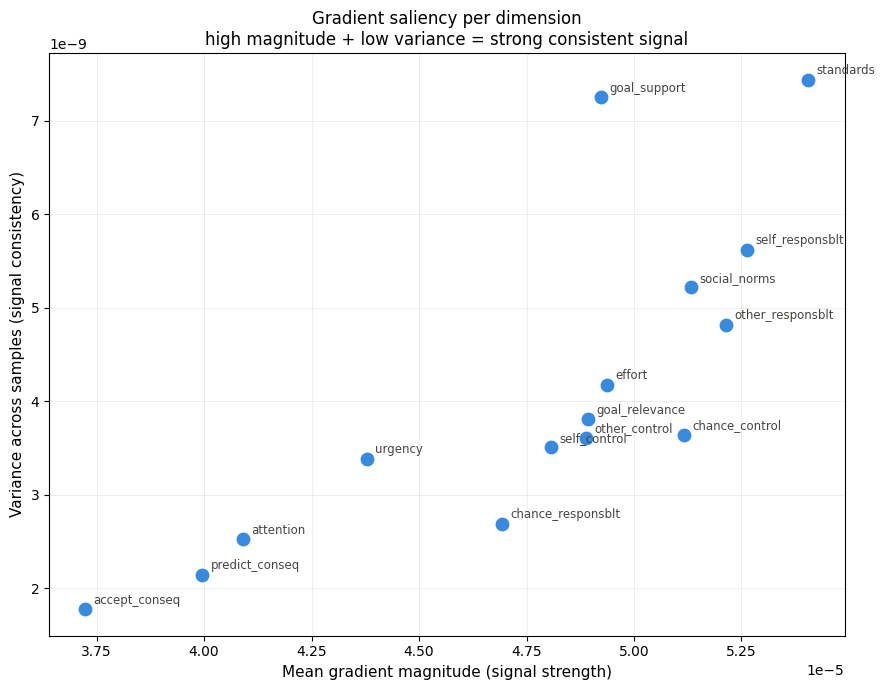

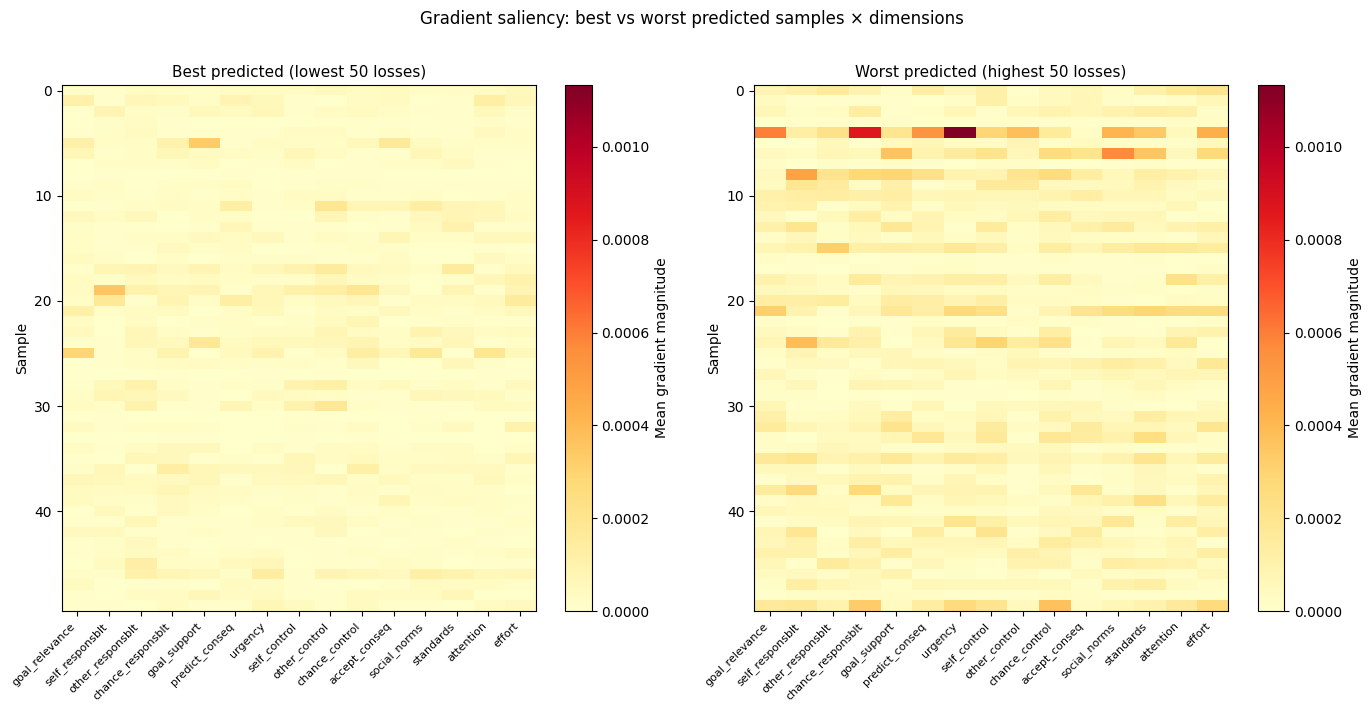

In [20]:
# Need these to mask padding
all_masks = np.concatenate([
    batch['attention_mask'].numpy() for batch in test_loader
], axis=0)

all_saliency = run_full_saliency(model, test_loader, TARGET_DIMS, device)
stats = aggregate_saliency_stats(all_saliency, all_masks)

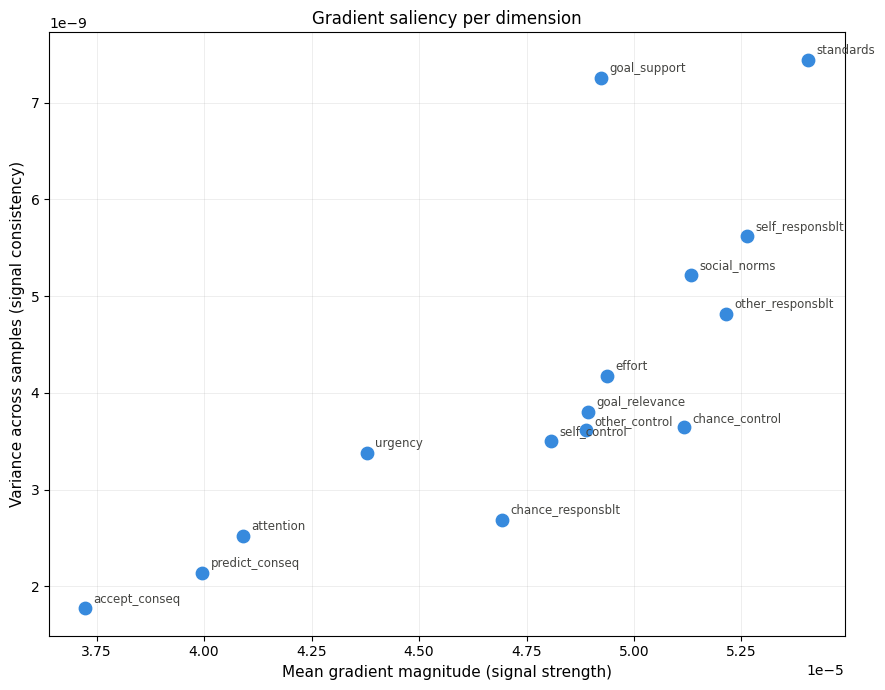

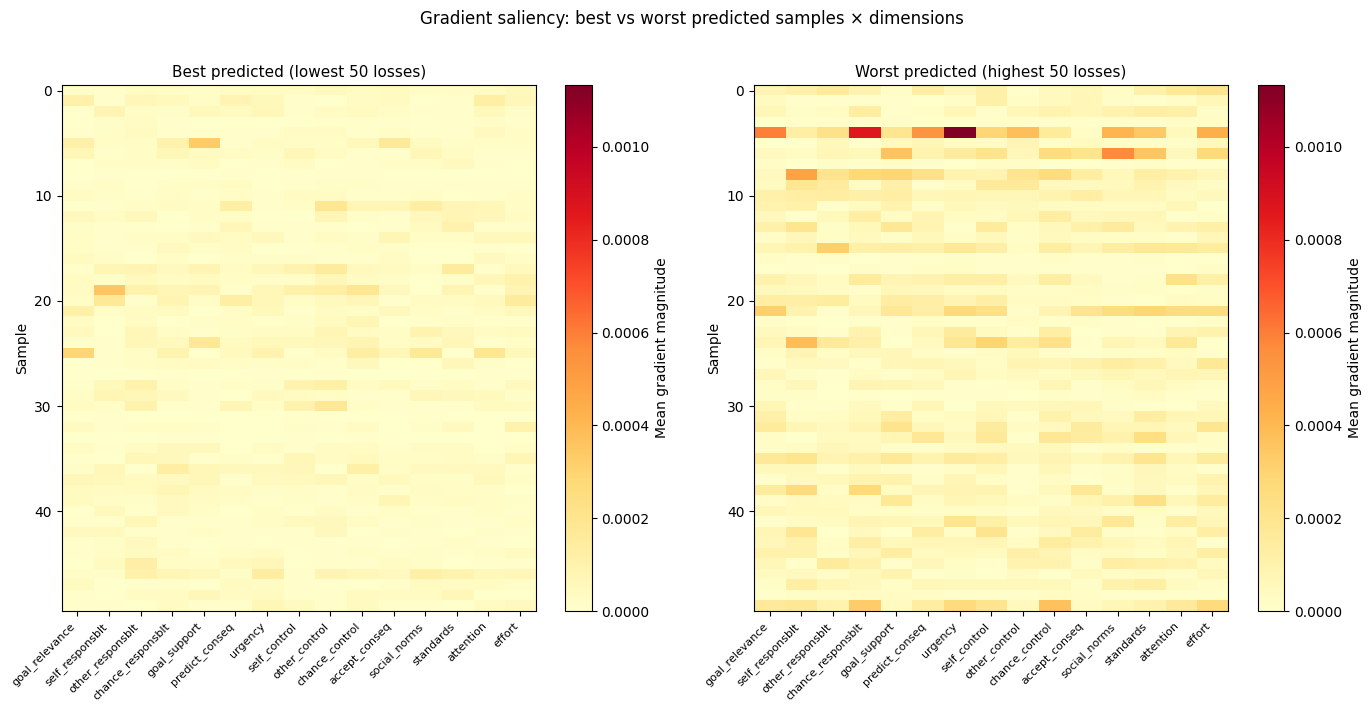

In [31]:
scatter_save_path = OUTPUTS_PATH + '/saliency_scatter_plot.png'
heatmap_save_path = OUTPUTS_PATH + '/saliency_heatmap.png'
plot_saliency_scatter(stats, TARGET_DIMS, 
                      save_path=scatter_save_path)

sample_losses = pd.read_csv(OUTPUTS_PATH + '/test_predictions-1781330953.csv')['sample_loss'].values
plot_saliency_heatmap(stats, TARGET_DIMS, sample_losses,
                      save_path=heatmap_save_path)

In [23]:
for dim, info in stats.items(): 
    print(f'{dim}: mean = {info['mean']}, variance = {info['variance']}')

goal_relevance: mean = 4.8935444915558414e-05, variance = 3.806072905134322e-09
self_responsblt: mean = 5.262292292147322e-05, variance = 5.619447502720376e-09
other_responsblt: mean = 5.21442558969857e-05, variance = 4.817465713856038e-09
chance_responsblt: mean = 4.693917595164844e-05, variance = 2.6870730342983187e-09
goal_support: mean = 4.9239769666937484e-05, variance = 7.2539889323314235e-09
predict_conseq: mean = 3.995451107601404e-05, variance = 2.1419167940105636e-09
urgency: mean = 4.3782071196135144e-05, variance = 3.382521841165435e-09
self_control: mean = 4.806375535740625e-05, variance = 3.5050247634910373e-09
other_control: mean = 4.8890066834807824e-05, variance = 3.6104979909915813e-09
chance_control: mean = 5.116128408402976e-05, variance = 3.6432300487419845e-09
accept_conseq: mean = 3.723701633790901e-05, variance = 1.7727128839305734e-09
social_norms: mean = 5.132676375956587e-05, variance = 5.2188295282494485e-09
standards: mean = 5.4058894201493514e-05, variance